In [2]:
import scanpy as sc

In [3]:
import pandas as pd
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt
#from matplotlib import rcParams
sc.settings.figdir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean/figures/"
########
outdir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/"
bname="major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk_clean"
adata=sc.read(f"{outdir}/clean/{bname}.h5ad")

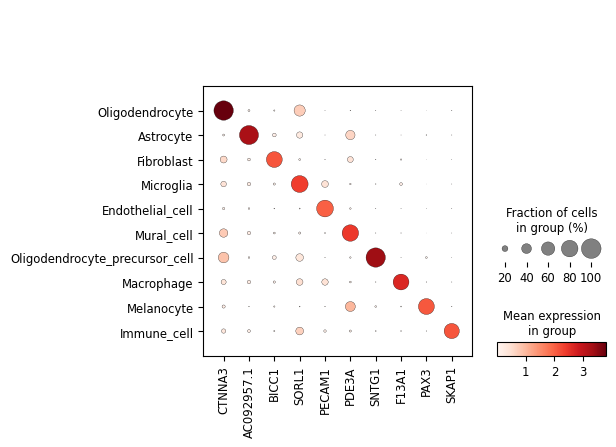

In [11]:
mk=["CTNNA3", "AC092957.1", "BICC1", "SORL1", "PECAM1", "PDE3A", "SNTG1", "F13A1", "PAX3", "SKAP1"]
order=["Oligodendrocyte",    "Astrocyte", "Fibroblast", "Microglia", "Endothelial_cell", "Mural_cell", "Oligodendrocyte_precursor_cell", "Macrophage", "Melanocyte", "Immune_cell"]
plt.rcParams["figure.figsize"] = (5,5)

sc.pl.dotplot(adata, mk, groupby="majorclass1", use_raw=True, save=f'_{bname}_mk.pdf', categories_order
=order)

In [10]:
adata.obs["majorclass1"].value_counts()

majorclass1
Oligodendrocyte                   278509
Astrocyte                         208786
Fibroblast                        112466
Microglia                          48062
Endothelial_cell                   33657
Mural_cell                         16937
Oligodendrocyte_precursor_cell     13919
Macrophage                          9801
Melanocyte                          8286
Immune_cell                         3941
Name: count, dtype: int64

/tmp/ipykernel_1940152/449386116.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


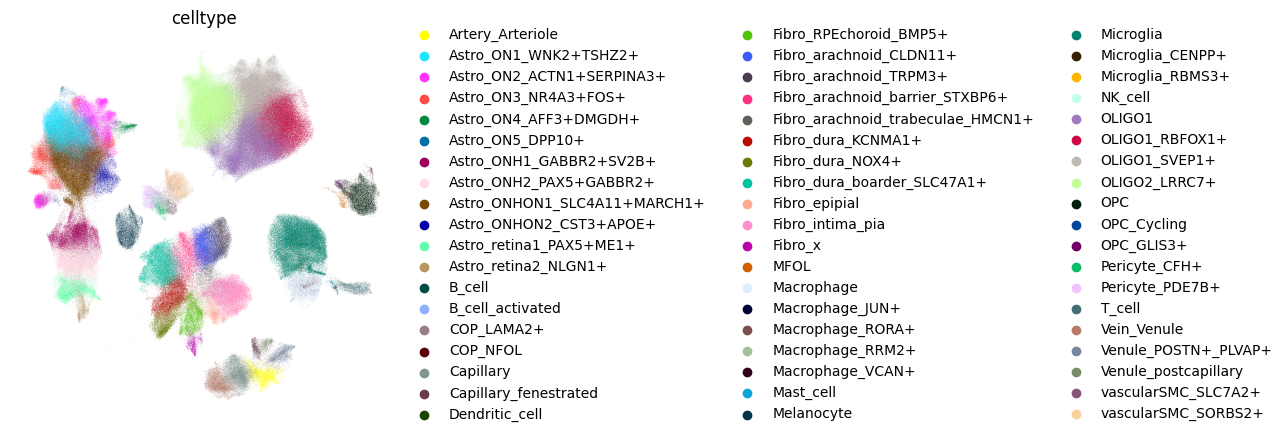

In [16]:

plt.rcParams["figure.figsize"] = (5,5)

#sc.pl.umap(adata, color="sampleid", frameon=False, save=f'_{bname}_sampleid5.png')

cmap = cm.get_cmap('tab20')
#colors = [to_hex(cmap(i)) for i in range(adata.obs["celltype"].nunique())]

import numpy as np
from matplotlib.colors import to_hex
n = adata.obs["celltype"].nunique()
colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n)]
#colors = [to_hex(cmap(i)) for i in range(n)]

#sc.pl.umap(adata, color="celltype", frameon=False, palette=colors, save=f'_{bname}_celltype5.png')
sc.pl.umap(adata, color="celltype", frameon=False, palette=sc.pl.palettes.default_102, save=f'_{bname}_celltype6.png')


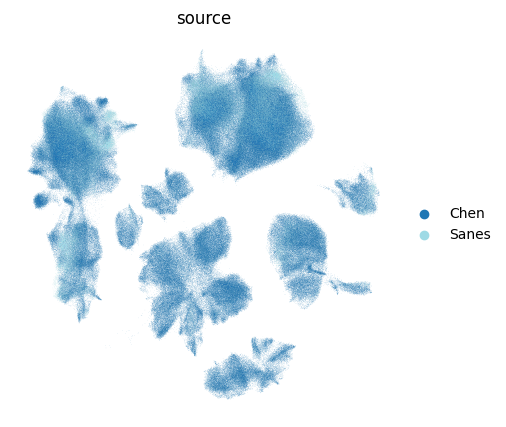

In [15]:
sc.pl.umap(adata, color="source", frameon=False, save=f'_{bname}_source.png')

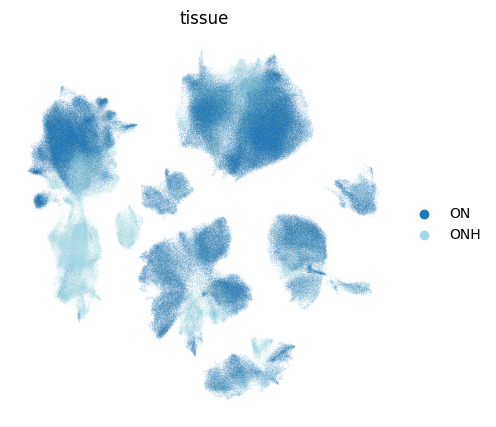

In [16]:
sc.pl.umap(adata, color="tissue", frameon=False, save=f'_{bname}_tissue.png')

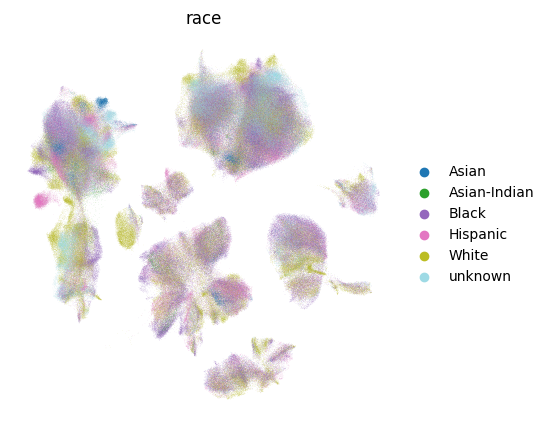

In [18]:
sc.pl.umap(adata, color="race", frameon=False, save=f'_{bname}_race.png')

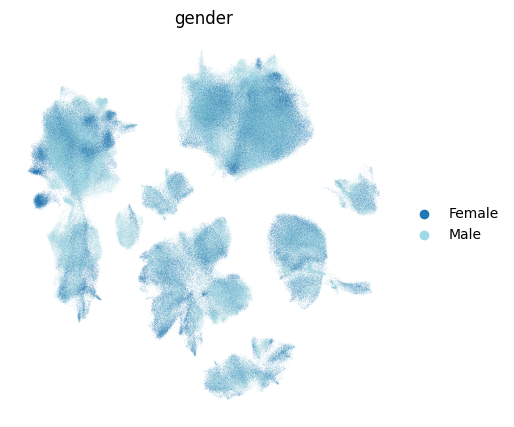

In [19]:
sc.pl.umap(adata, color="gender", frameon=False, save=f'_{bname}_gender.png')

In [29]:
adata.obs[["donor","race"]].drop_duplicates().groupby(["race"]).size()

/tmp/ipykernel_3711239/3466386746.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[["donor","race"]].drop_duplicates().groupby(["race"]).size()


race
Asian            4
Asian-Indian     1
Black           24
Hispanic        17
White           21
unknown         16
dtype: int64

In [30]:
adata.obs[["donor","gender"]].drop_duplicates().groupby(["gender"]).size()

/tmp/ipykernel_3711239/2877567788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[["donor","gender"]].drop_duplicates().groupby(["gender"]).size()


gender
Female    29
Male      54
dtype: int64

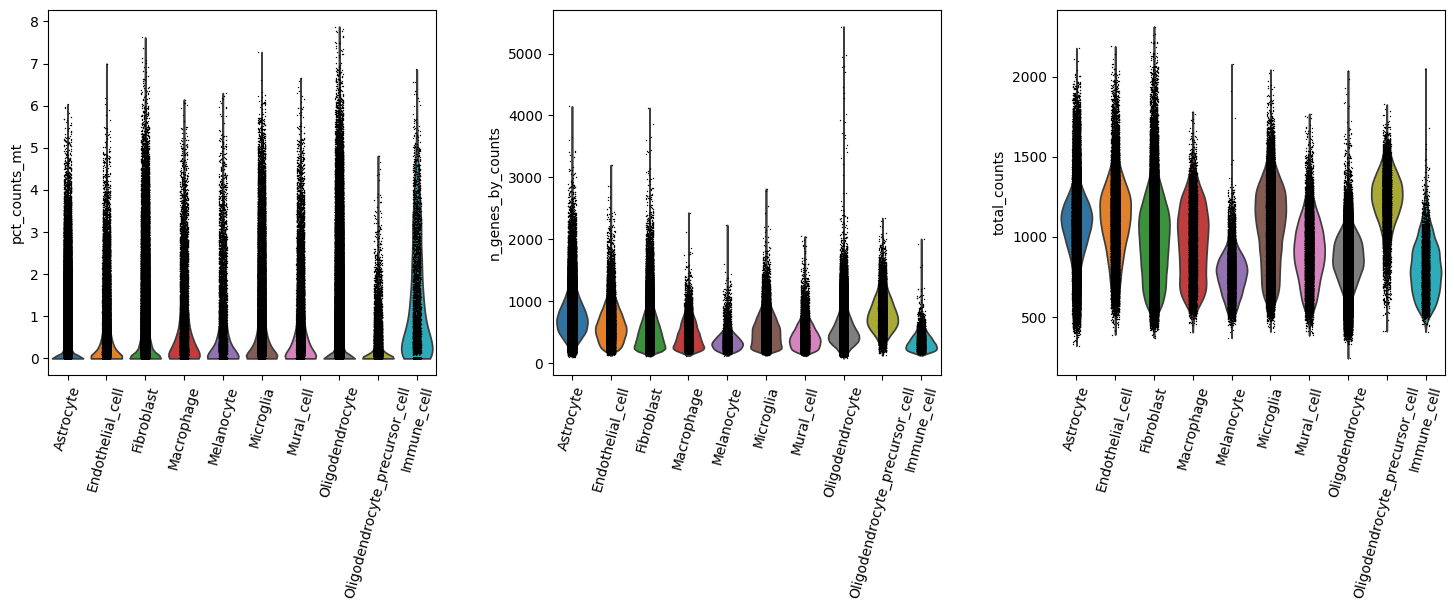

In [31]:
sc.pl.violin(adata,keys=["pct_counts_mt","n_genes_by_counts", "total_counts"], groupby="majorclass1", rotation=75, save=f"_{bname}_QC.png", multi_panel=True)

In [35]:
adata.obs[["nCount_RNA","source","majorclass1"]].groupby(["majorclass1","source"]).count().to_csv(f"{outdir}/clean/{bname}_source.csv")
df=pd.read_csv(f"{outdir}/clean/{bname}_source.csv")

/tmp/ipykernel_3711239/1495585306.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs[["nCount_RNA","source","majorclass1"]].groupby(["majorclass1","source"]).count().to_csv(f"{outdir}/clean/{bname}_source.csv")


In [36]:
f"{outdir}/clean/{bname}_source.csv"

'/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major//clean/major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk_clean_source.csv'

In [1]:
import scanpy as sc

In [2]:
adata=sc.read("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/Astrocyte/clean/Astrocyte_subclass_new5_clean_celltype.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 208786 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pANN', 'DF.classifications', 'reactionid', 'sampleid', 'donor', 'race', 'gender', 'age', 'tissue', 'suspension', 'technology', 'sampleid_legacy', '_scvi_batch', '_scvi_labels', 'majorclass', 'majorclass1', 'source', 'age_year', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden1', 'subclass', 'celltype', 'subclass1', 'subclass2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_subclass', 'gender_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'race_colors', 'rank_genes_groups', 'sampleid_colors', 'source_colors', 'subclass_colors', 'tissue_colors', '

In [5]:
adata.obs["celltype"].value_counts()

celltype
Astro_ONHON1_SLC4A11+MARCH1+    46938
Astro_ON1_WNK2+TSHZ2+           46633
Astro_ON2_ACTN1+SERPINA3+       25433
Astro_ON3_NR4A3+FOS+            23740
Astro_ONH2_PAX5+GABBR2+         21654
Astro_ONH1_GABBR2+SV2B+         18364
Astro_ONHON2_CST3+APOE+         10734
Astro_retina1_PAX5+ME1+          9938
Astro_retina2_NLGN1+             2744
Astro_ON4_AFF3+DMGDH+            2066
Astro_ON5_DPP10+                  542
Name: count, dtype: int64

In [6]:
obs=adata.obs

In [11]:
obs["celltype1"]=obs["celltype"].astype("str")
obs.loc[obs["celltype"].isin(["Astro_ON1_WNK2+TSHZ2+", "Astro_ON2_ACTN1+SERPINA3+", "Astro_ON3_NR4A3+FOS+", "Astro_ON4_AFF3+DMGDH+", "Astro_ON5_DPP10+"]),"celltype1"]="Astro_ON"

In [12]:
obs.loc[obs["celltype"].isin(["Astro_retina1_PAX5+ME1+", "Astro_retina2_NLGN1+"]),"celltype1"]="Astro_retina"

In [13]:
obs["celltype1"].value_counts()

celltype1
Astro_ON                        98414
Astro_ONHON1_SLC4A11+MARCH1+    46938
Astro_ONH2_PAX5+GABBR2+         21654
Astro_ONH1_GABBR2+SV2B+         18364
Astro_retina                    12682
Astro_ONHON2_CST3+APOE+         10734
Name: count, dtype: int64

In [14]:
obs.to_csv("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/Astrocyte/clean/Astrocyte_subclass_new5_clean_celltype.obs.gz")

In [18]:
adata1=adata
adata1.obs=obs.loc[adata1.obs.index]

In [17]:
len(obs)

208786

In [20]:
adata1.obs["celltype1"].value_counts()

celltype1
Astro_ON                        98414
Astro_ONHON1_SLC4A11+MARCH1+    46938
Astro_ONH2_PAX5+GABBR2+         21654
Astro_ONH1_GABBR2+SV2B+         18364
Astro_retina                    12682
Astro_ONHON2_CST3+APOE+         10734
Name: count, dtype: int64

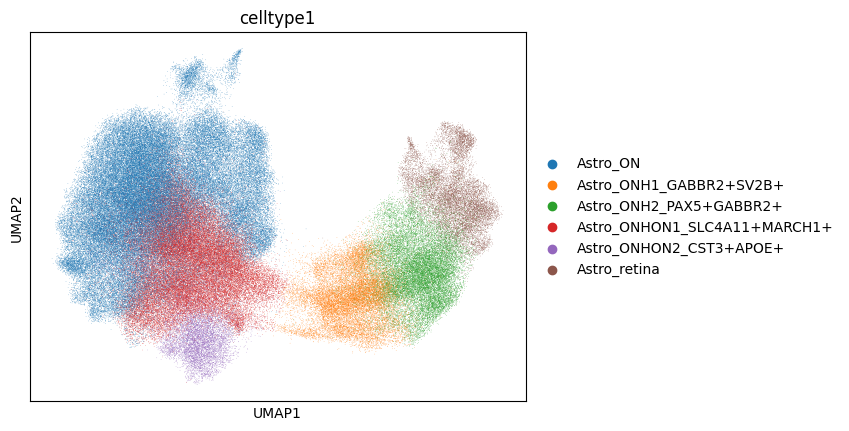

In [21]:
sc.pl.umap(adata1, color="celltype1")

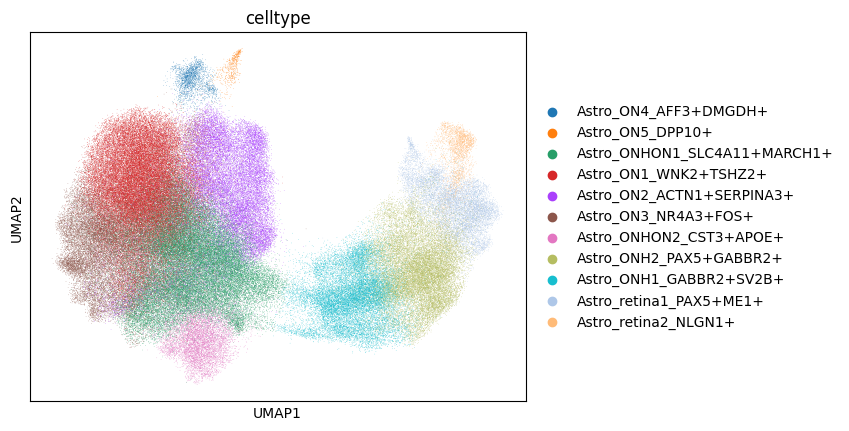

In [22]:
sc.pl.umap(adata1, color="celltype")

In [24]:
adata1.write("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/Astrocyte/clean/Astrocyte_subclass_new5_clean_celltype_update.h5ad")

In [25]:
import pandas as pd

In [30]:
obs=pd.read_csv("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean/major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk_clean.obs.gz", header=0, index_col=0, sep="\t")

/tmp/ipykernel_1014007/1802815711.py:1: DtypeWarning: Columns (12,27) have mixed types. Specify dtype option on import or set low_memory=False.
  obs=pd.read_csv("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean/major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk_clean.obs.gz", header=0, index_col=0, sep="\t")


In [38]:
obs.loc[obs["tissue"]=="ON","donor"].nunique()

63

In [44]:
obs.loc[obs["tissue"]=="ONH","sampleid"].count()

194347

In [33]:
obs["age_year"].max()

90

In [34]:
obs["age_year"].min()

0

In [1]:
import scanpy as sc
adata=sc.read("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/lattice_update_final/ONONH_all_raw_normcount_only.h5ad")

In [2]:
import pandas as pd
data=pd.read_csv("/dfs3b/ruic20_lab/junw42/HCA_ON/data/7_DEG/genexp_sample_raw_atlas_meta_gsm_race_batch_sampleid", header=0, index_col=0)

In [3]:
data

,donor,race,gender,age,tissue,age_year,globe,pmit,batch
sampleid,,,,,,,,,
A230245_Atlanta_ONH_RNA,A230245_Atlanta,Black,Female,65,ONH,65,NotApplicable,NotApplicable,A23
A230245_Atlanta_ON_RNA,A230245_Atlanta,Black,Female,65,ON,65,NotApplicable,NotApplicable,A23
BCM_22_0047_ONH_RNA,BCM_22_0047,White,Male,70,ONH,70,NotApplicable,8,BCM
BCM_22_0047_ON_RNA,BCM_22_0047,White,Male,70,ON,70,NotApplicable,8,BCM
BCM_22_0101_ON_RNA_s2,BCM_22_0101,White,Male,61,ON,61,NotApplicable,9,BCM
...,...,...,...,...,...,...,...,...,...
MMD_23_21623_ONH_RNA,MMD_23_21623,Black,Male,15,ONH,15,OD,22.93,MMD
MMD_23_21999_ONH_RNA,MMD_23_21999,Black,Male,17,ONH,17,OD,9.17,MMD
MMD_23_22486_ONH_RNA,MMD_23_22486,White,Male,3,ONH,3,OS,17.8,MMD


In [5]:
n=adata.obs["sampleid"].value_counts().reset_index()

In [6]:
n

,sampleid,count
0,BCM_22_0784_ON_RNA,36315
1,MMD_23_17738_ON_RNA,17804
2,BCM_22_0896_ON_RNA,16251
3,MMD_23_16055_ON_RNA,14808
4,BCM_22_0849_ON_RNA,13929
...,...,...
109,BCM_22_0528_ONH_RNA,593
110,BCM_23_0358_ONH_RNA,366
111,BCM_23_0792_ONH_RNA,318
112,BCM_23_0574_ONH_RNA,175


In [9]:
data.index.difference(n["sampleid"])

Index([], dtype='object', name='sampleid')

In [1]:
import scanpy as sc

In [2]:
import scanpy as sc

from matplotlib import rcParams
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches

rcParams["figure.figsize"] = (5,5)
rcParams.update({'font.size': 14})

In [3]:
sc.settings.figdir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/Astrocyte/clean/veloc/"

In [4]:
adata=sc.read("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/Astrocyte/clean/veloc/Astrocyte_subclass_new5_clean_hvg_5000_raw_velocity.h5ad")

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [8]:
dt={"Astro_ON4_AFF3+DMGDH+": "Astro_ON4", "Astro_ON5_DPP10+": "Astro_ON5", "Astro_ONHON1_SLC4A11+MARCH1+": "Astro_ONHON1", "Astro_ON1_WNK2+TSHZ2+": "Astro_ON1", "Astro_ON2_ACTN1+SERPINA3+": "Astro_ON2", "Astro_ON3_NR4A3+FOS+": "Astro_ON3", "Astro_ONHON2_CST3+APOE+": "Astro_ONHON2", "Astro_ONH2_PAX5+GABBR2+": "Astro_ONH2", "Astro_ONH1_GABBR2+SV2B+": "Astro_ONH1", "Astro_retina1_PAX5+ME1+": "Astro_retina1", "Astro_retina2_NLGN1+": "Astro_retina2"}
adata.obs["subclass1"]=adata.obs["subclass"].astype("str").replace(dt)
order=["Astro_ON5", "Astro_ON4", "Astro_ON3", "Astro_ON2", "Astro_ON1", "Astro_ONHON1", "Astro_ONHON2", "Astro_ONH1", "Astro_ONH2", "Astro_retina1", "Astro_retina2" ]

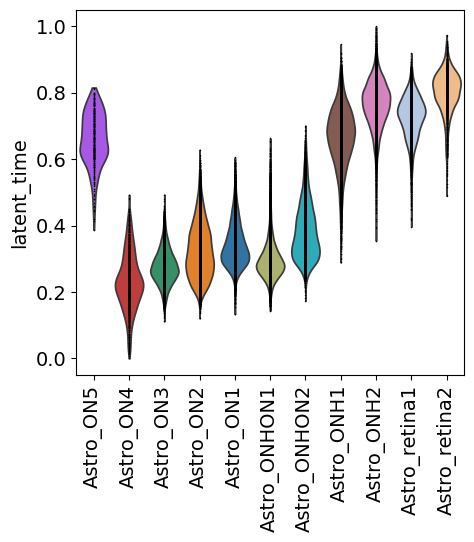

In [9]:
sc.pl.violin(adata, "latent_time",groupby="subclass1", order=order, save="_astro_latent_time_reorder.pdf",rotation=90, jitter=False)

In [7]:
adata.obs["subclass1"].value_counts()

subclass1
Astro_ONHON1     46938
Astro_ON1        46633
Astro_ON2        25433
Astro_NO3        23740
Astro_ONH2       21654
Astro_ONH1       18364
Astro_ONHON2     10734
Astro_retina1     9938
Astro_retina2     2744
Astro_ON4         2066
Astro_NO5          542
Name: count, dtype: int64